<center>
    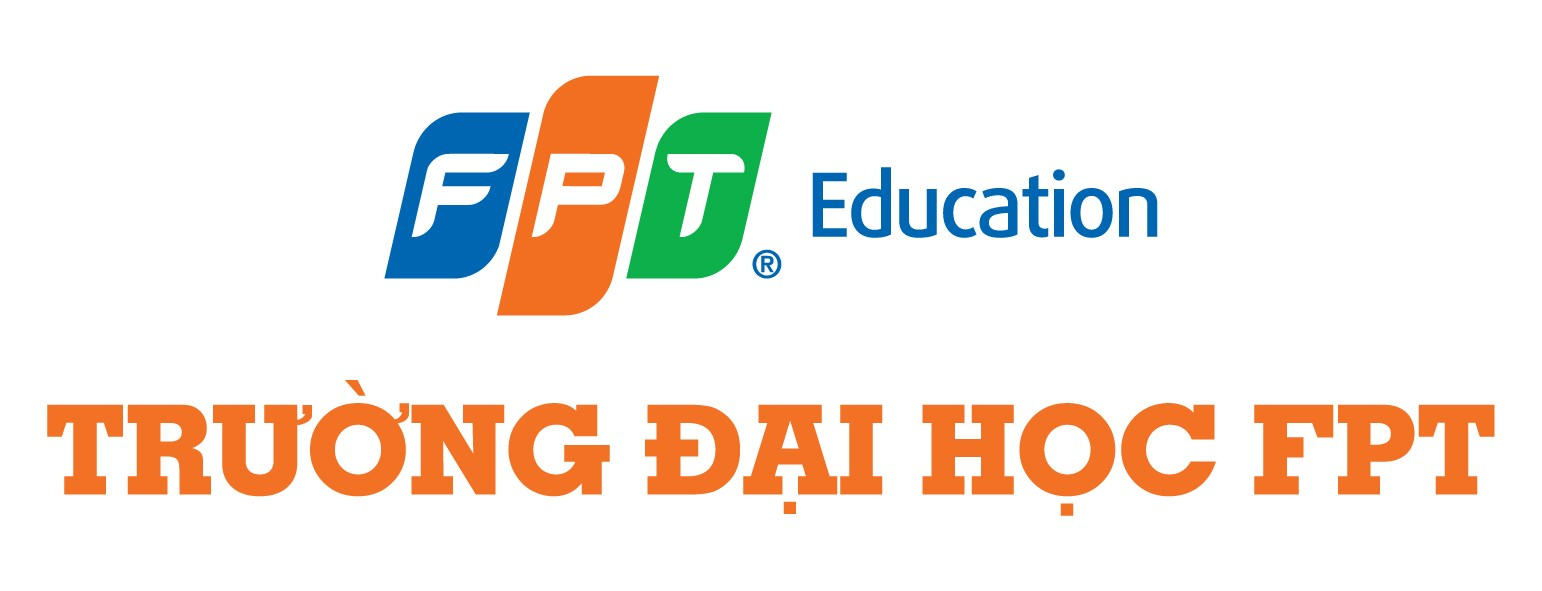
    
# Reinforcement Learning 
# Lab 3 â€” Function Approximation in Reinforcement Learning
</center>



<br>

#### Class name: AI1902-AA____________________

#### Student code: HE195216__________________

#### Student name: Duong Ngoc Anh___________________

<br>

<a alt='AI1902'></a>
## CartPole-v1 with Linear Semi-gradient Control

In this lab, you will train an agent for the **CartPole-v1** environment using **linear function approximation** and **stacked action features**.

You may implement **one** of the following algorithms:

1. **Semi-gradient Q-learning** *(recommended)*, or  
2. **Semi-gradient SARSA**.

You are **not allowed** to use built-in RL libraries that directly implement Q-learning, SARSA, DQN, PPO, Actor-Critic, or other RL trainers. You must implement the learning logic yourself.

Estimated time needed: **120 minutes**

<h3 style='color:red;'>Note: After submitting the assignment, students may be asked oral questions to demonstrate their understanding of function approximation, TD error, epsilon-greedy exploration, and stacked action features.</h3>

## Learning Objectives

After completing this lab, you should be able to:

1. explain why tabular Q-learning is not suitable for continuous state spaces;
2. construct a feature vector $\phi(s)$ for a continuous state;
3. construct stacked action features $\phi(s,a)$;
4. implement an epsilon-greedy policy using approximate Q-values;
5. implement semi-gradient SARSA or semi-gradient Q-learning;
6. plot reward curves and evaluate the learned policy;
7. run inference with GUI rendering using the trained policy.

## 1. Introduction

<center><img src='cart_pole.gif' width = 200/></center>

The **CartPole-v1** environment is a classic control problem. The goal is to keep a pole balanced on a moving cart for as long as possible.

| &nbsp; | &nbsp; |
| :--- | :--- |
| Environment | `CartPole-v1` |
| Action Space | `Discrete(2)` |
| Observation Space | Continuous vector with 4 values |
| Import | `gymnasium.make("CartPole-v1")` |
| Goal | Keep the pole upright |
| Reward | Usually +1 for each time step survived |

### CartPole state vector

At each step, the observation is a vector with 4 components:

| Index | Meaning |
| :---: | :--- |
| 0 | Cart position |
| 1 | Cart velocity |
| 2 | Pole angle |
| 3 | Pole angular velocity |

Because the state is continuous, a tabular Q-table is not a natural choice.  
Instead, we will approximate the action-value function with a linear model.

### From tabular Q-values to approximate Q-values

In tabular Q-learning, we store one value for each pair $(s,a)$:

$$
Q(s,a)
$$

In function approximation, we estimate the value using features and weights:

$$
\hat{Q}(s,a;\mathbf{w}) = \mathbf{w}^\top \phi(s,a)
$$

where:

- $\phi(s,a)$ is the feature vector for the state-action pair,
- $\mathbf{w}$ is the weight vector to be learned.

In [1]:
# Install Gymnasium if needed:
# !pip install gymnasium[classic-control]

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

random_seed = 42
np.random.seed(random_seed)

## Task 1 â€” Setup and Random Baseline

### Requirement

1. Create the `CartPole-v1` environment.
2. Print the action space and observation space.
3. Run a random policy for 100 episodes.
4. Report average return, average episode length, maximum return, and minimum return.

### Hint

In Gymnasium, each `env.step(action)` returns:

```python
next_state, reward, terminated, truncated, info = env.step(action)
```

An episode ends when:

```python
done = terminated or truncated
```

In [2]:
# Task 1 â€” Setup and Random Baseline

env = gym.make("CartPole-v1")
state, info = env.reset(seed=random_seed)
env.action_space.seed(random_seed)

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Initial state:", state)

def run_random_policy(env, n_episodes=100, seed=42):
    returns = []
    lengths = []

    for episode in range(n_episodes):
        state, info = env.reset(seed=seed + episode)
        done = False
        total_reward = 0.0
        steps = 0

        # TODO 1:
        # Run one episode using random actions.
        # Use env.action_space.sample() to sample actions.
        # Update total_reward and steps.
        # Stop when terminated or truncated is True.
        #
        # while not done:
        #     action = ...
        #     next_state, reward, terminated, truncated, info = ...
        #     done = ...
        #     total_reward += ...
        #     steps += ...
        #     state = ...

        while not done:
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1
            state = next_state

        returns.append(total_reward)
        lengths.append(steps)

    return returns, lengths

random_returns, random_lengths = run_random_policy(env, n_episodes=100, seed=random_seed)

print("Random policy results")
print("Average return:", np.mean(random_returns))
print("Average episode length:", np.mean(random_lengths))
print("Maximum return:", np.max(random_returns))
print("Minimum return:", np.min(random_returns))

Action space: Discrete(2)
Observation space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
Initial state: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Random policy results
Average return: 25.22
Average episode length: 25.22
Maximum return: 87.0
Minimum return: 9.0


## Task 2 â€” Feature Vector Construction $\phi(s)$

`CartPole-v1` has a continuous state:

$$
s = [x, \dot{x}, \theta, \dot{\theta}]
$$

where $x$ is cart position, $\dot{x}$ is cart velocity, $\theta$ is pole angle, and $\dot{\theta}$ is pole angular velocity.

### Requirement

Implement tile-coded state features. Each state should activate one tile in each tiling. If we use `NUM_TILINGS = 8`, then each state should activate 8 binary features.

### Expected Output

Your feature vector $\phi(s)$ should be sparse and binary.

In [3]:
# Task 2 â€” Feature Vector Construction phi(s)

NUM_TILINGS = 8
TILE_BINS = np.array([8, 8, 8, 8], dtype=np.int64)

# Region of interest for CartPole.
# Cart position termination is around +/-2.4.
# Pole angle termination is around +/-12 degrees = +/-0.2095 rad.
# Velocities are clipped to reasonable values for feature construction.
TILE_LOW = np.array([-2.4, -3.0, -0.2095, -3.5], dtype=np.float64)
TILE_HIGH = np.array([2.4, 3.0, 0.2095, 3.5], dtype=np.float64)

TILE_WIDTH = (TILE_HIGH - TILE_LOW) / (TILE_BINS - 1)
TILES_PER_TILING = int(np.prod(TILE_BINS))
NUM_STATE_FEATURES = NUM_TILINGS * TILES_PER_TILING

def clip_state_for_features(state):
    state = np.asarray(state, dtype=np.float64)
    return np.clip(state, TILE_LOW, TILE_HIGH)

def tiling_offset(tiling_id):
    """
    Return the offset for a specific tiling.
    Different tilings should use different offsets.
    """
    multipliers = np.array([1, 3, 5, 7], dtype=np.float64)
    fractions = ((tiling_id * multipliers) % NUM_TILINGS) / NUM_TILINGS
    return fractions * TILE_WIDTH

def active_state_feature_indices(state):
    """
    Return the active tile-coded feature indices for state s.

    Returns:
        active_indices: numpy array with length NUM_TILINGS
    """
    s = clip_state_for_features(state)
    active_indices = []

    for tiling_id in range(NUM_TILINGS):
        offset = tiling_offset(tiling_id)
        coordinates = np.floor((s - TILE_LOW + offset) / TILE_WIDTH).astype(int)
        coordinates = np.clip(coordinates, 0, TILE_BINS - 1)
        tile_id = np.ravel_multi_index(tuple(coordinates), tuple(TILE_BINS))
        global_id = tiling_id * TILES_PER_TILING + tile_id
        active_indices.append(global_id)
        

    return np.array(active_indices, dtype=np.int64)

def state_features(state):
    """
    Construct dense binary feature vector phi(s).
    This function is useful for explanation and checking.
    The training loop can use sparse active indices for efficiency.
    """
    phi = np.zeros(NUM_STATE_FEATURES, dtype=np.float64)

    active_idx = active_state_feature_indices(state)
    phi[active_idx] = 1.0

    return phi

# Test feature construction
state, info = env.reset(seed=random_seed)
active_idx = active_state_feature_indices(state)
phi = state_features(state)

print("State:", state)
print("Number of tilings:", NUM_TILINGS)
print("Tiles per tiling:", TILES_PER_TILING)
print("State feature dimension:", NUM_STATE_FEATURES)
print("Number of active state features:", int(phi.sum()))
print("Active state feature indices:", active_idx)

State: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Number of tilings: 8
Tiles per tiling: 4096
State feature dimension: 32768
Number of active state features: 8
Active state feature indices: [ 1763  5860 10020 14052 18660 22819 26851 31011]


## Task 3 â€” Stacked Action Features $\phi(s,a)$

For action-value approximation, features must depend on both state and action.

For two actions:

$$
\phi(s,0) = [\phi(s), 0]
$$

$$
\phi(s,1) = [\phi(s), 1]
$$

Only the feature block corresponding to the selected action is active.

### Requirement

Implement:

1. `active_state_action_feature_indices(state, action, n_actions)`
2. `stacked_action_features(state, action, n_actions)`
3. `q_value(state, action, weights, n_actions)`
4. `q_values_all_actions(state, weights, n_actions)`

In [4]:
# Task 3 â€” Stacked Action Features phi(s,a)

def active_state_action_feature_indices(state, action, n_actions):
    """
    Return active feature indices for stacked action features phi(s,a).
    """
    state_indices = active_state_feature_indices(state)
    offset = action * NUM_STATE_FEATURES
    return state_indices + offset

def stacked_action_features(state, action, n_actions):
    """
    Construct dense stacked action feature vector phi(s,a).
    """
    phi_sa = np.zeros(n_actions * NUM_STATE_FEATURES, dtype=np.float64)

    active_idx = active_state_action_feature_indices(state, action, n_actions)
    phi_sa[active_idx] = 1.0

    return phi_sa

def q_value(state, action, weights, n_actions):
    """
    Compute Q_hat(s,a;w).
    Since phi(s,a) is binary and sparse, Q_hat is the sum of active weights.
    """
    active_idx = active_state_action_feature_indices(state, action, n_actions)
    return np.sum(weights[active_idx])

def q_values_all_actions(state, weights, n_actions):
    """
    Compute Q-values for all actions.
    """
    return np.array([q_value(state, action, weights, n_actions) for action in range(n_actions)])

# Test stacked features
n_actions = env.action_space.n
num_total_features = n_actions * NUM_STATE_FEATURES
weights = np.zeros(num_total_features, dtype=np.float64)

print("Number of actions:", n_actions)
print("Total stacked feature dimension:", num_total_features)
print("Q-values with zero weights:", q_values_all_actions(state, weights, n_actions))

Number of actions: 2
Total stacked feature dimension: 65536
Q-values with zero weights: [0. 0.]


## Task 4 â€” Epsilon-greedy Policy

The agent uses epsilon-greedy exploration:

- with probability $\epsilon$, choose a random action;
- with probability $1-\epsilon$, choose the action with the largest estimated Q-value.

### Requirement

Implement `epsilon_greedy_action`.

In [5]:
# Task 4 â€” Epsilon-greedy Policy

def random_argmax(values, rng):
    """
    Return a random index among all maximum-value indices.
    This avoids always selecting the first action when Q-values are tied.
    """
    values = np.asarray(values)
    max_value = np.max(values)
    candidates = np.flatnonzero(np.isclose(values, max_value))
    return int(rng.choice(candidates))

def epsilon_greedy_action(state, weights, n_actions, epsilon, rng):
    """
    Select an action using epsilon-greedy exploration.
    """
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))
    q_values = q_values_all_actions(state, weights, n_actions)
    return random_argmax(q_values, rng)


# Test epsilon-greedy
rng = np.random.default_rng(random_seed)

for eps in [1.0, 0.5, 0.0]:
    actions = [epsilon_greedy_action(state, weights, n_actions, eps, rng) for _ in range(10)]
    print(f"epsilon={eps}: actions={actions}")

epsilon=1.0: actions=[1, 0, 0, 0, 1, 1, 1, 0, 0, 1]
epsilon=0.5: actions=[0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
epsilon=0.0: actions=[0, 1, 0, 0, 1, 0, 1, 0, 0, 0]


## Task 5 â€” Semi-gradient SARSA or Semi-gradient Q-learning

This lab supports both algorithms.

### Semi-gradient SARSA

$$
\delta_t = R_{t+1} + \gamma \hat{Q}(S_{t+1}, A_{t+1};\mathbf{w}) - \hat{Q}(S_t,A_t;\mathbf{w})
$$

### Semi-gradient Q-learning

$$
\delta_t = R_{t+1} + \gamma \max_{a'} \hat{Q}(S_{t+1}, a';\mathbf{w}) - \hat{Q}(S_t,A_t;\mathbf{w})
$$

### Weight Update

$$
\mathbf{w} \leftarrow \mathbf{w} + \alpha \delta_t \phi(S_t,A_t)
$$

Because $\phi(s,a)$ is sparse and binary, we only need to update the active weights.

### Important Implementation Requirement

Use an explicit maximum number of steps per episode:

```python
for step in range(max_steps_per_episode):
    ...
```

This prevents the training cell from running indefinitely.

In [6]:
# Task 5 â€” Semi-gradient SARSA or Semi-gradient Q-learning

def shaped_training_reward(next_state, env_reward, terminated, truncated):
    """
    Reward used for learning only.

    The original CartPole reward is +1 at every step.
    This shaped reward gives a clearer failure signal during training.
    Evaluation will still use the original reward.
    """
    if terminated:
        return -10.0

    x, x_dot, theta, theta_dot = next_state

    x_penalty = 0.10 * abs(x) / 2.4
    theta_penalty = 0.50 * abs(theta) / 0.2095

    return 1.0 - x_penalty - theta_penalty

def evaluate_greedy_policy(env, weights, n_episodes=20, seed=1000, max_steps_per_episode=500):
    """
    Evaluate the learned greedy policy.
    """
    returns = []
    lengths = []
    n_actions = env.action_space.n
    rng = np.random.default_rng(seed)

    for episode in range(n_episodes):
        state, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        steps = 0

        for step in range(max_steps_per_episode):
            action = epsilon_greedy_action(state, weights, n_actions, 0.0, rng)
            next_state, env_reward, terminated, truncated, _info = env.step(action)
            done = terminated or truncated
            total_reward += env_reward
            steps += 1
            state = next_state
            if done:
                break

        returns.append(total_reward)
        lengths.append(steps)

    return returns, lengths

def train_agent(
    env,
    algorithm="sarsa",
    num_episodes=1000,
    alpha=0.1 / NUM_TILINGS,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.995,
    use_reward_shaping=True,
    max_steps_per_episode=500,
    eval_every=100,
    eval_episodes=5,
    solved_score=475,
    progress_every=100,
    seed=42
):
    """
    Train a CartPole agent using linear function approximation with tile coding.

    Args:
        algorithm: "sarsa" or "q_learning"
    """
    if algorithm not in ["sarsa", "q_learning"]:
        raise ValueError("algorithm must be either 'sarsa' or 'q_learning'")

    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    n_actions = env.action_space.n
    weights = np.zeros(n_actions * NUM_STATE_FEATURES, dtype=np.float64)

    episode_returns = []
    episode_lengths = []
    epsilon_history = []

    eval_checkpoints = []
    eval_mean_returns = []

    epsilon = epsilon_start

    for episode in range(num_episodes):
        state, info = env.reset(seed=seed + episode)
        total_original_reward = 0.0
        steps = 0

        if algorithm == "sarsa":
            action = epsilon_greedy_action(state, weights, n_actions, epsilon, rng)

        for step in range(max_steps_per_episode):
            if algorithm == "q_learning":
                action = epsilon_greedy_action(state, weights, n_actions, epsilon, rng)

            # Step the environment
            next_state, env_reward, terminated, truncated, _info = env.step(action)
            done = terminated or truncated

            # Original reward for episode return
            total_original_reward += env_reward

            # Compute learning reward
            if use_reward_shaping:
                learning_reward = shaped_training_reward(next_state, env_reward, terminated, truncated)
            else:
                learning_reward = env_reward

            # Get active indices for current state-action
            active_idx = active_state_action_feature_indices(state, action, n_actions)
            current_q = np.sum(weights[active_idx])

            # Compute TD target
            if done:
                target = learning_reward
            elif algorithm == "q_learning":
                next_q_values = q_values_all_actions(next_state, weights, n_actions)
                target = learning_reward + gamma * np.max(next_q_values)
            else:  # sarsa
                next_action = epsilon_greedy_action(next_state, weights, n_actions, epsilon, rng)
                next_active_idx = active_state_action_feature_indices(next_state, next_action, n_actions)
                target = learning_reward + gamma * np.sum(weights[next_active_idx])

            # TD error and weight update
            delta = target - current_q
            weights[active_idx] += alpha * delta

            steps += 1
            state = next_state

            # SARSA: update action for next step
            if algorithm == "sarsa" and not done:
                action = epsilon_greedy_action(state, weights, n_actions, epsilon, rng)

            if done:
                break

        episode_returns.append(total_original_reward)
        episode_lengths.append(steps)
        epsilon_history.append(epsilon)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        if (episode + 1) % eval_every == 0:
            eval_returns, _ = evaluate_greedy_policy(
                env,
                weights,
                n_episodes=eval_episodes,
                seed=seed + 10000 + episode,
                max_steps_per_episode=max_steps_per_episode
            )
            eval_mean = float(np.mean(eval_returns))
            eval_checkpoints.append(episode + 1)
            eval_mean_returns.append(eval_mean)

        if progress_every is not None and (episode + 1) % progress_every == 0:
            recent_train_mean = np.mean(episode_returns[-progress_every:])
            msg = (
                f"Episode {episode + 1:4d}/{num_episodes} | "
                f"epsilon={epsilon:.3f} | "
                f"recent train mean={recent_train_mean:.1f}"
            )
            if len(eval_mean_returns) > 0:
                msg += f" | last greedy eval={eval_mean_returns[-1]:.1f}"
            print(msg)

        if len(eval_mean_returns) >= 3 and np.mean(eval_mean_returns[-3:]) >= solved_score:
            print(f"Early stopping at episode {episode + 1}.")
            break

    info = {
        "eval_checkpoints": eval_checkpoints,
        "eval_mean_returns": eval_mean_returns,
        "algorithm": algorithm,
        "alpha": alpha,
        "gamma": gamma,
        "use_reward_shaping": use_reward_shaping,
        "max_steps_per_episode": max_steps_per_episode
    }

    return weights, episode_returns, episode_lengths, epsilon_history, info  # type: tuple[np.ndarray, list[float], list[int], list[float], dict]

# Train the agent
training_env = gym.make("CartPole-v1")

weights, episode_returns, episode_lengths, epsilon_history, train_info = train_agent(
    training_env,
    algorithm="sarsa",
    num_episodes=1000,
    alpha=0.1 / NUM_TILINGS,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.02,
    epsilon_decay=0.995,
    use_reward_shaping=True,
    max_steps_per_episode=500,
    eval_every=100,
    eval_episodes=5,
    solved_score=475,
    progress_every=100,
    seed=random_seed
)

training_env.close()

print("Training completed.")
print("Algorithm:", train_info["algorithm"])
print("Alpha:", train_info["alpha"])
print("Gamma:", train_info["gamma"])
print("Reward shaping:", train_info["use_reward_shaping"])
print("Max steps per episode:", train_info["max_steps_per_episode"])
print("Episodes actually run:", len(episode_returns))
print("Average training return over all episodes:", np.mean(episode_returns))
print("Average training return over last 100 episodes:", np.mean(episode_returns[-100:]))
print("Maximum training return:", np.max(episode_returns))
print("Minimum training return:", np.min(episode_returns))

if len(train_info["eval_mean_returns"]) > 0:
    print("Last greedy evaluation mean:", train_info["eval_mean_returns"][-1])

Episode  100/1000 | epsilon=0.606 | recent train mean=27.5 | last greedy eval=70.4
Episode  200/1000 | epsilon=0.367 | recent train mean=76.2 | last greedy eval=284.2
Episode  300/1000 | epsilon=0.222 | recent train mean=235.1 | last greedy eval=395.2
Episode  400/1000 | epsilon=0.135 | recent train mean=352.2 | last greedy eval=442.0
Episode  500/1000 | epsilon=0.082 | recent train mean=441.0 | last greedy eval=500.0
Episode  600/1000 | epsilon=0.049 | recent train mean=440.6 | last greedy eval=498.2
Early stopping at episode 600.
Training completed.
Algorithm: sarsa
Alpha: 0.0125
Gamma: 0.99
Reward shaping: True
Max steps per episode: 500
Episodes actually run: 600
Average training return over all episodes: 262.1066666666667
Average training return over last 100 episodes: 440.56
Maximum training return: 500.0
Minimum training return: 10.0
Last greedy evaluation mean: 498.2


## Task 6 â€” Reward Curve, Average Reward, and Explanation

### Requirement

After training, report:

1. training reward curve;
2. epsilon decay curve;
3. greedy evaluation curve;
4. average test reward after training;
5. explanation of the role of $\phi(s)$ and $\phi(s,a)$.

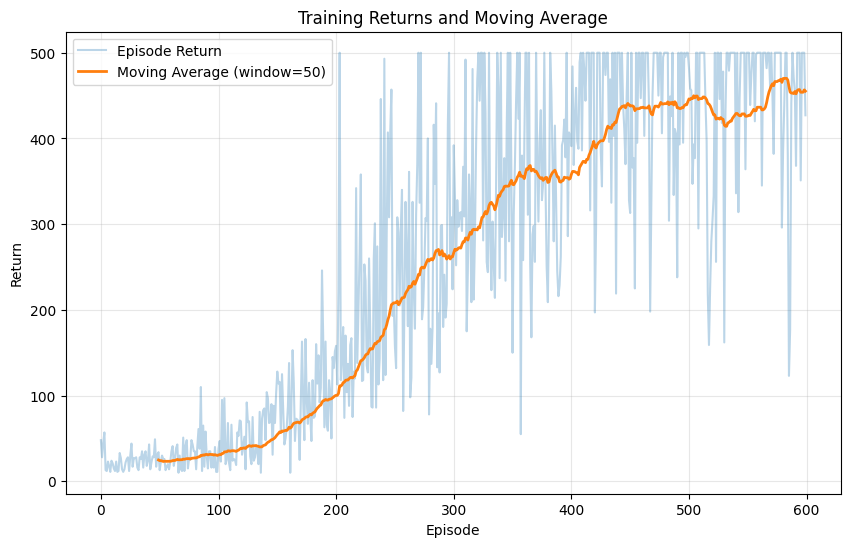

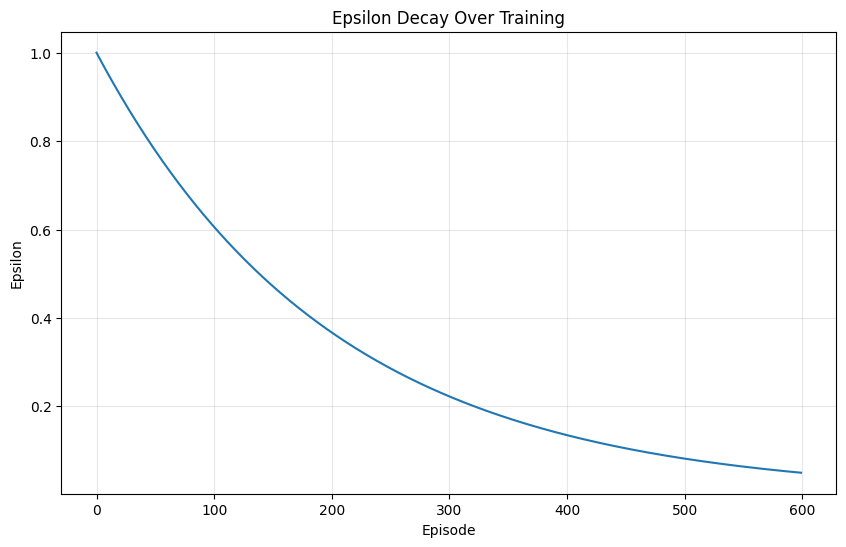

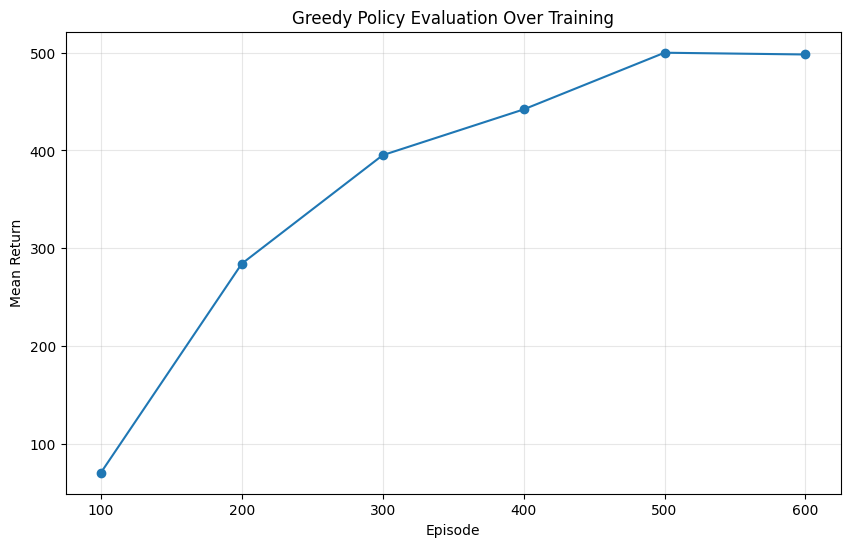

Final Greedy Policy Evaluation (100 episodes):
  Average return: 443.93
  Std return: 79.58
  Min return: 201.00
  Max return: 500.00
EXPLANATION OF FEATURE VECTORS

1. Role of phi(s) (state features):
   - phi(s) is a tile-coded feature vector that discretizes the continuous
     4-dimensional state space into binary features.
   - Each state activates exactly NUM_TILINGS=8 binary features (one per tiling).
   - Tile coding allows generalization across similar states while maintaining
     distinct values for different regions of the state space.
   - The 8 different tilings with offsets provide additional generalization
     and reduce approximation error.

2. Role of phi(s,a) (state-action features):
   - phi(s,a) stacks NUM_ACTIONS copies of phi(s), one for each action.
   - Only the features corresponding to the selected action are activated.
   - This allows the linear model to estimate Q(s,a) for different actions
     using shared features but separate weight blocks.
   - The Q

In [7]:
# Task 6 â€” Reward Curve, Average Reward, and Explanation

def moving_average(values, window=50):
    values = np.asarray(values, dtype=np.float64)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode="valid")

window = 50
ma_returns = moving_average(episode_returns, window=window)

# Plot training return and moving average
plt.figure(figsize=(10, 6))
plt.plot(episode_returns, alpha=0.3, label='Episode Return')
plt.plot(range(window-1, len(episode_returns)), ma_returns, label=f'Moving Average (window={window})', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Training Returns and Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot epsilon decay
plt.figure(figsize=(10, 6))
plt.plot(epsilon_history)
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Epsilon Decay Over Training')
plt.grid(True, alpha=0.3)
plt.show()

# Plot greedy evaluation curve
plt.figure(figsize=(10, 6))
plt.plot(train_info["eval_checkpoints"], train_info["eval_mean_returns"], marker='o')
plt.xlabel('Episode')
plt.ylabel('Mean Return')
plt.title('Greedy Policy Evaluation Over Training')
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate final greedy policy over 100 episodes
final_eval_env = gym.make("CartPole-v1")
final_returns, final_lengths = evaluate_greedy_policy(
    final_eval_env,
    weights,
    n_episodes=100,
    seed=99999,
    max_steps_per_episode=500
)
final_eval_env.close()

print(f"Final Greedy Policy Evaluation (100 episodes):")
print(f"  Average return: {np.mean(final_returns):.2f}")
print(f"  Std return: {np.std(final_returns):.2f}")
print(f"  Min return: {np.min(final_returns):.2f}")
print(f"  Max return: {np.max(final_returns):.2f}")

# Explanation of the feature vectors

print("=" * 60)
print("EXPLANATION OF FEATURE VECTORS")
print("=" * 60)

print("""
1. Role of phi(s) (state features):
   - phi(s) is a tile-coded feature vector that discretizes the continuous
     4-dimensional state space into binary features.
   - Each state activates exactly NUM_TILINGS=8 binary features (one per tiling).
   - Tile coding allows generalization across similar states while maintaining
     distinct values for different regions of the state space.
   - The 8 different tilings with offsets provide additional generalization
     and reduce approximation error.

2. Role of phi(s,a) (state-action features):
   - phi(s,a) stacks NUM_ACTIONS copies of phi(s), one for each action.
   - Only the features corresponding to the selected action are activated.
   - This allows the linear model to estimate Q(s,a) for different actions
     using shared features but separate weight blocks.
   - The Q-value is computed as the sum of weights for active features.

3. Why function approximation for CartPole-v1:
   - CartPole-v1 has continuous state space (4 continuous dimensions).
   - Tabular Q-learning would require discretizing the space into bins,
     leading to the curse of dimensionality.
   - With tile coding, we can represent the state space efficiently using
     sparse binary features (only 8 active out of 32768 dimensions).
   - Linear function approximation with tile coding is efficient and can
     generalize well across the continuous state space.

4. Why SARSA is often more stable than Q-learning:
   - SARSA is on-policy: it learns from the actions the agent actually takes.
   - Q-learning is off-policy: it learns from the greedy action even when
     the agent explores. This can lead to overestimation errors.
   - With function approximation, Q-learning's overestimation can compound
     and lead to instability or divergence.
   - SARSA's conservative updates make it more stable for control tasks.
""")

## Inference with GUI Rendering

After training, run the learned greedy policy and render the environment.

### Requirement

Use:

```python
gym.make("CartPole-v1", render_mode="human")
```

This opens a GUI window on a local machine.

### Notes

- `render_mode="human"` is suitable for local Jupyter Notebook or Python scripts.
- It may not work on remote servers or Google Colab because they usually do not support GUI windows.
- The inference policy should use `epsilon=0.0`, meaning greedy action selection.

In [8]:
import time

def run_inference_with_gui(weights, n_episodes=3, seed=5000, max_steps_per_episode=500, sleep_time=0.02):
    """
    Run the trained greedy policy with GUI rendering.

    This function uses render_mode="human", so it should open a CartPole GUI window
    when running on a local machine.

    Args:
        weights: learned weight vector after training
        n_episodes: number of inference episodes
        seed: random seed for evaluation episodes
        max_steps_per_episode: hard limit for each episode
        sleep_time: delay between steps to make GUI movement easier to observe
    """
    render_env = gym.make("CartPole-v1", render_mode="human")
    n_actions = render_env.action_space.n
    rng = np.random.default_rng(seed)

    try:
        for episode in range(n_episodes):
            state, info = render_env.reset(seed=seed + episode)

            total_reward = 0.0
            steps = 0

            for step in range(max_steps_per_episode):
                # Greedy action selection: epsilon = 0.0
                action = epsilon_greedy_action(
                    state=state,
                    weights=weights,
                    n_actions=n_actions,
                    epsilon=0.0,
                    rng=rng
                )

                next_state, reward, terminated, truncated, info = render_env.step(action)

                total_reward += reward
                steps += 1
                state = next_state

                # Small delay so the GUI animation is easier to see
                time.sleep(sleep_time)

                if terminated or truncated:
                    break

            print(f"Episode {episode + 1}: return = {total_reward}, steps = {steps}")

    finally:
        render_env.close()


# Run inference with the trained policy
run_inference_with_gui(
    weights=weights,
    n_episodes=3,
    seed=5000,
    max_steps_per_episode=500,
    sleep_time=0.02
)

c:\Users\DELL\anaconda3\envs\atari-rl\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode 1: return = 500.0, steps = 500
Episode 2: return = 500.0, steps = 500
Episode 3: return = 500.0, steps = 500


## Optional â€” RGB Array Rendering for Notebook-only Environments

If `render_mode="human"` does not work because you are using a remote notebook environment, you can use `render_mode="rgb_array"` and display frames inside the notebook. This is not required for the main submission if you are running the lab locally.

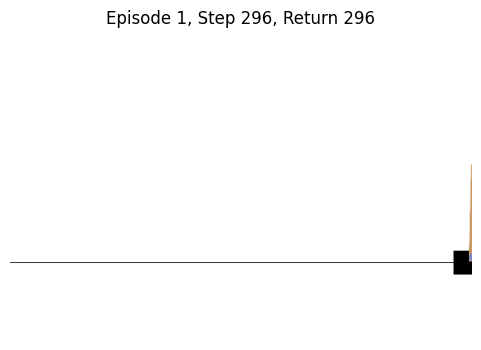

Episode 1: return = 296.0


In [10]:
# Optional fallback for remote notebooks: render_mode="rgb_array"
# This is optional and may be slower.

from IPython.display import clear_output, display


def run_inference_rgb_array(weights, n_episodes=1, seed=6000, max_steps_per_episode=500):
    render_env = gym.make("CartPole-v1", render_mode="rgb_array")
    n_actions = render_env.action_space.n
    rng = np.random.default_rng(seed)

    for episode in range(n_episodes):
        state, info = render_env.reset(seed=seed + episode)
        total_reward = 0.0

        for step in range(max_steps_per_episode):
            action = epsilon_greedy_action(state, weights, n_actions, epsilon=0.0, rng=rng)
            next_state, reward, terminated, truncated, info = render_env.step(action)
            frame = render_env.render()

            plt.figure(figsize=(6, 4))
            plt.imshow(frame)
            plt.axis("off")
            plt.title(f"Episode {episode + 1}, Step {step + 1}, Return {total_reward + reward:.0f}")
            clear_output(wait=True)
            display(plt.gcf())
            plt.close()

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        print(f"Episode {episode + 1}: return = {total_reward}")

    render_env.close()

# Uncomment this only if render_mode="human" is not available.
run_inference_rgb_array(weights, n_episodes=1, seed=6000)

## Submission Requirements

Submit your completed notebook with:

1. all TODO sections completed;
2. output of random policy baseline;
3. training reward curve;
4. epsilon decay curve;
5. greedy evaluation curve;
6. final average reward after training;
7. short explanation of the feature vector;
8. inference code with `render_mode="human"`.

### Suggested Questions to Answer

1. Why is tabular Q-learning not suitable for `CartPole-v1`?
2. What is the role of tile coding?
3. What is the role of stacked action features?
4. Why is SARSA often more stable than Q-learning with function approximation?
5. Does tile coding still count as linear function approximation? Why?